# Single-timestep PNG NMR workflow demo

This notebook demonstrates one complete NMR workflow for one RTSPHEM timestep:

1. Geometry import and bbox size check
2. Editable parameter block
3. PNG pixel decay solve
4. PNG triangular-mesh decay solve and mesh preview
5. COMSOL / PNG pixel / PNG triangular decay and T2 inversion comparison
6. Timing summary

Every run creates a timestamped output folder under the selected experiment directory.

## 1. Parameter entry

Edit this cell when switching experiment folders, timestep, or numerical/physical parameters. The defaults below run `exp_015`, `timestep=15`.

In [1]:

from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# Input path and timestep
# -----------------------------------------------------------------------------
EXP_DIR = Path(r"C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015")
TIMESTEP = 25

# Project directory. The unicode escapes keep this notebook runnable with
# `jupyter run` on Windows consoles that default to cp1252.
PROJECT_DIR = Path("C:/Users/imgw/Documents/Codex/NMR\u6a21\u62df")
ADVANCED_TOOLS_DIR = PROJECT_DIR / "advanced_tools"
PNG_DECAY_SCRIPT = ADVANCED_TOOLS_DIR / "png_phase_nmr_decay.py"
PYGIMLI_FALLBACK_PYTHON = Path(r"C:\Python314\python.exe")

# -----------------------------------------------------------------------------
# Geometry interpretation
# -----------------------------------------------------------------------------
USE_NONWHITE_BBOX_FOR_GEOMETRY_SIZE = True
MAX_GRID_SIZE = 500

# -----------------------------------------------------------------------------
# Physical parameters
# -----------------------------------------------------------------------------
DIFFUSION_UM2_PER_MS = 2.0
BULK_T2_MS = 3000.0
RHO_SOLID_UM_PER_MS = 0.05
RHO_GAS_UM_PER_MS = 0.0

# -----------------------------------------------------------------------------
# Decay solver parameters
# -----------------------------------------------------------------------------
DECAY_DT_MS = 5.0
DECAY_T_MAX_MS = 5500.0

# -----------------------------------------------------------------------------
# GPU pixel solver parameters
# -----------------------------------------------------------------------------
# True: run the extra PNG pixel GPU method. False: skip it and keep the notebook
# as the original COMSOL / PNG pixel / PNG triangular comparison.
ENABLE_PIXEL_GPU = True

# "cg" is the recommended CUDA sparse solver here because the implicit-Euler
# matrix is symmetric positive definite. "factorized" and "spsolve" are kept as
# debugging options but can be less stable on some CUDA/cuSPARSE combinations.
PIXEL_GPU_SOLVER = "cg"  # "cg", "factorized", or "spsolve"
PIXEL_GPU_CG_TOL = 1e-8
PIXEL_GPU_CG_MAXITER = 2000

# True means: if CUDA is unavailable or the GPU solve fails, record the reason
# and continue with COMSOL / CPU pixel / triangular mesh. Set False when you
# want the notebook to stop immediately on GPU failure.
SKIP_PIXEL_GPU_ON_ERROR = True

# -----------------------------------------------------------------------------
# Triangular mesh parameters
# -----------------------------------------------------------------------------
TRI_MESH_BULK_SIZE_UM = 16.0
TRI_MESH_BOUNDARY_SIZE_UM = 5.0
TRI_MESH_MAX_POINTS = 25000

# -----------------------------------------------------------------------------
# T2 inversion parameters
# -----------------------------------------------------------------------------
NNLS_ALPHA = 0.1
T2_MIN_MS = 1.0
T2_MAX_MS = 100000.0
T2_NUM_BINS = 240

# -----------------------------------------------------------------------------
# Output directory. Each run is separated by timestamp.
# -----------------------------------------------------------------------------
RUN_ID = f"single_timestep_nmr_demo_t{TIMESTEP:04d}_" + datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = EXP_DIR / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=False)

INTERFACE_DIR = EXP_DIR / "interface_images"
COMSOL_DIR = EXP_DIR / "comsol_results"
CONCENTRATION_DIR = EXP_DIR / "individual_plots" / "concentration"
METADATA_JSON = EXP_DIR / "run_metadata.json"
TIME_CSV = EXP_DIR / "global_evolution_log.csv"

PNG_PATH = INTERFACE_DIR / f"timestep_{TIMESTEP:04d}.png"
COMSOL_XLSX = COMSOL_DIR / f"T2_t{TIMESTEP:04d}.xlsx"
CONCENTRATION_PNG = CONCENTRATION_DIR / f"concentration_{TIMESTEP:04d}.png"

print("RUN_DIR:", RUN_DIR)
print("PNG:", PNG_PATH)
print("COMSOL:", COMSOL_XLSX)
print("Concentration:", CONCENTRATION_PNG)


RUN_DIR: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836
PNG: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\interface_images\timestep_0025.png
COMSOL: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\comsol_results\T2_t0025.xlsx
Concentration: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\individual_plots\concentration\concentration_0025.png


## 2. Imports and helper setup

In [2]:

import csv
import json
import os
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as IPyImage, Markdown, display
from PIL import Image

sys.path.insert(0, str(PROJECT_DIR))

import advanced_tools.run_four_way_nmr_comparison_gpu as gpu_workflow
from advanced_tools.compare_png_nmr_with_comsol import (
    invert_fixed_alpha,
    normalize,
    read_comsol_probe_excel,
    read_png_decay_csv,
    trim_to_decay,
)
from advanced_tools.png_phase_nmr_decay import (
    OUTSIDE,
    SimulationParams,
    classify_png,
    downsample_nearest,
    sample_bbox,
    simulate_png,
)

try:
    import pygimli as pg
    CURRENT_PYTHON_HAS_PYGIMLI = True
except Exception:
    CURRENT_PYTHON_HAS_PYGIMLI = False

for path in [EXP_DIR, PNG_PATH, COMSOL_XLSX, METADATA_JSON]:
    if not path.exists():
        raise FileNotFoundError(path)

print("Current Python:", sys.executable)
print("Current Python has pyGIMLI:", CURRENT_PYTHON_HAS_PYGIMLI)
print("Fallback pyGIMLI Python:", PYGIMLI_FALLBACK_PYTHON)
def gpu_runtime_status():
    if not gpu_workflow.CUPY_AVAILABLE:
        return False, "CuPy import failed"
    try:
        count = int(gpu_workflow.cp.cuda.runtime.getDeviceCount())
        if count < 1:
            return False, "CuPy imported, but no CUDA device is visible"
        name = gpu_workflow.cp.cuda.runtime.getDeviceProperties(0)["name"].decode("utf-8", errors="replace")
        return True, f"{count} CUDA device(s), first device: {name}"
    except Exception as exc:
        return False, f"CuPy imported, but CUDA runtime check failed: {type(exc).__name__}: {exc}"

GPU_RUNTIME_AVAILABLE, GPU_RUNTIME_MESSAGE = gpu_runtime_status()

print("Current Python has CuPy import:", gpu_workflow.CUPY_AVAILABLE)
print("CUDA runtime available:", GPU_RUNTIME_AVAILABLE)
print("CUDA runtime message:", GPU_RUNTIME_MESSAGE)


Current Python: c:\Users\imgw\.conda\envs\ml\python.exe
Current Python has pyGIMLI: False
Fallback pyGIMLI Python: C:\Python314\python.exe
Current Python has CuPy import: True
CUDA runtime available: True
CUDA runtime message: 1 CUDA device(s), first device: NVIDIA GeForce RTX 4070 Ti SUPER


## 3. Geometry import and size check

C:\Users\imgw\AppData\Local\Temp\ipykernel_42672\1408694117.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,timestep,geometry_mode,length_x_um,length_y_um,raw_width_px,raw_height_px,bbox_col_min,bbox_col_max,bbox_row_min,bbox_row_max,bbox_width_px,bbox_height_px,pixel_size_x_um,pixel_size_y_um,outside_px,water_px,solid_px
0,25,nonwhite bbox,995.0,980.0,1343,808,361,1028,61,718,668,658,1.489521,1.489362,645600,350508,89036


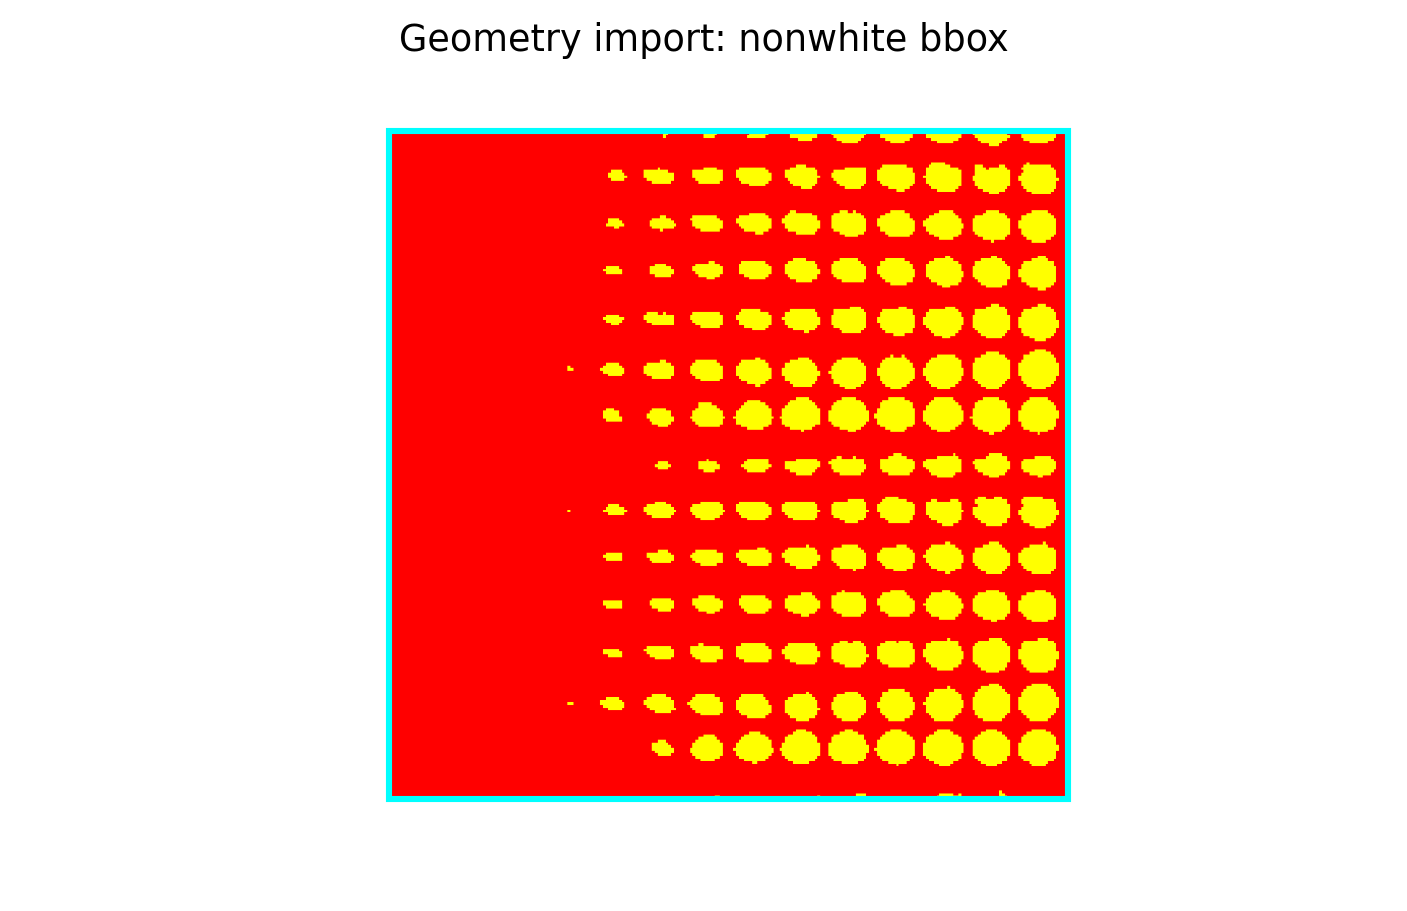

In [3]:
metadata = json.loads(METADATA_JSON.read_text(encoding="utf-8"))
params = metadata["parameters"]
length_x_um = float(params["lengthXAxis_cm"]) * 10000.0
length_y_um = float(params["lengthYAxis_cm"]) * 10000.0

rgb = np.asarray(Image.open(PNG_PATH).convert("RGB"))
labels = classify_png(rgb)
raw_height, raw_width = labels.shape

if USE_NONWHITE_BBOX_FOR_GEOMETRY_SIZE:
    r_min, r_max, c_min, c_max = sample_bbox(labels)
    bbox_height = r_max - r_min + 1
    bbox_width = c_max - c_min + 1
    pixel_size_x_um = length_x_um / bbox_width
    pixel_size_y_um = length_y_um / bbox_height
    geometry_mode = "nonwhite bbox"
else:
    r_min, r_max, c_min, c_max = 0, raw_height - 1, 0, raw_width - 1
    bbox_height = raw_height
    bbox_width = raw_width
    pixel_size_x_um = length_x_um / raw_width
    pixel_size_y_um = length_y_um / raw_height
    geometry_mode = "full PNG"

geometry_dir = RUN_DIR / "01_geometry"
geometry_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(rgb)
rect = plt.Rectangle((c_min, r_min), bbox_width, bbox_height, fill=False, color="cyan", lw=2)
ax.add_patch(rect)
ax.set_title(f"Geometry import: {geometry_mode}")
ax.set_axis_off()
geometry_png = geometry_dir / f"timestep_{TIMESTEP:04d}_geometry_bbox.png"
fig.savefig(geometry_png, dpi=220, bbox_inches="tight")
plt.show()

geometry_summary = {
    "timestep": TIMESTEP,
    "geometry_mode": geometry_mode,
    "length_x_um": length_x_um,
    "length_y_um": length_y_um,
    "raw_width_px": raw_width,
    "raw_height_px": raw_height,
    "bbox_col_min": c_min,
    "bbox_col_max": c_max,
    "bbox_row_min": r_min,
    "bbox_row_max": r_max,
    "bbox_width_px": bbox_width,
    "bbox_height_px": bbox_height,
    "pixel_size_x_um": pixel_size_x_um,
    "pixel_size_y_um": pixel_size_y_um,
    "outside_px": int(np.sum(labels == 0)),
    "water_px": int(np.sum(labels == 1)),
    "solid_px": int(np.sum(labels == 2)),
}
pd.DataFrame([geometry_summary]).to_csv(geometry_dir / "geometry_summary.csv", index=False)
display(pd.DataFrame([geometry_summary]))
display(IPyImage(filename=str(geometry_png)))

## 4. Parameter table

In [4]:

parameter_table = pd.DataFrame([
    {"name": "DIFFUSION_UM2_PER_MS", "value": DIFFUSION_UM2_PER_MS, "note": "D, COMSOL 2e-9 m^2/s = 2 um^2/ms"},
    {"name": "BULK_T2_MS", "value": BULK_T2_MS, "note": "bulk T2"},
    {"name": "RHO_SOLID_UM_PER_MS", "value": RHO_SOLID_UM_PER_MS, "note": "solid-liquid surface relaxivity"},
    {"name": "RHO_GAS_UM_PER_MS", "value": RHO_GAS_UM_PER_MS, "note": "gas-liquid surface relaxivity"},
    {"name": "DECAY_DT_MS", "value": DECAY_DT_MS, "note": "decay time step"},
    {"name": "DECAY_T_MAX_MS", "value": DECAY_T_MAX_MS, "note": "maximum decay time"},
    {"name": "MAX_GRID_SIZE", "value": MAX_GRID_SIZE, "note": "largest image dimension after downsampling"},
    {"name": "ENABLE_PIXEL_GPU", "value": ENABLE_PIXEL_GPU, "note": "run extra CuPy/CUDA pixel solver"},
    {"name": "PIXEL_GPU_SOLVER", "value": PIXEL_GPU_SOLVER, "note": "GPU sparse solver: cg/factorized/spsolve"},
    {"name": "PIXEL_GPU_CG_TOL", "value": PIXEL_GPU_CG_TOL, "note": "CG tolerance for GPU pixel solver"},
    {"name": "PIXEL_GPU_CG_MAXITER", "value": PIXEL_GPU_CG_MAXITER, "note": "maximum CG iterations for GPU pixel solver"},
    {"name": "SKIP_PIXEL_GPU_ON_ERROR", "value": SKIP_PIXEL_GPU_ON_ERROR, "note": "continue notebook when CUDA/GPU solve is unavailable"},
    {"name": "TRI_MESH_BULK_SIZE_UM", "value": TRI_MESH_BULK_SIZE_UM, "note": "triangular mesh interior spacing"},
    {"name": "TRI_MESH_BOUNDARY_SIZE_UM", "value": TRI_MESH_BOUNDARY_SIZE_UM, "note": "triangular mesh boundary spacing"},
    {"name": "NNLS_ALPHA", "value": NNLS_ALPHA, "note": "fixed T2 inversion smoothing factor"},
    {"name": "T2_MIN_MS", "value": T2_MIN_MS, "note": "T2 inversion lower bound"},
    {"name": "T2_MAX_MS", "value": T2_MAX_MS, "note": "T2 inversion upper bound"},
    {"name": "T2_NUM_BINS", "value": T2_NUM_BINS, "note": "number of T2 bins"},
])
parameter_table.to_csv(RUN_DIR / "parameter_table.csv", index=False)
display(parameter_table)


,name,value,note
0,DIFFUSION_UM2_PER_MS,2.0,"D, COMSOL 2e-9 m^2/s = 2 um^2/ms"
1,BULK_T2_MS,3000.0,bulk T2
2,RHO_SOLID_UM_PER_MS,0.05,solid-liquid surface relaxivity
3,RHO_GAS_UM_PER_MS,0.0,gas-liquid surface relaxivity
4,DECAY_DT_MS,5.0,decay time step
5,DECAY_T_MAX_MS,5500.0,maximum decay time
6,MAX_GRID_SIZE,500,largest image dimension after downsampling
7,ENABLE_PIXEL_GPU,True,run extra CuPy/CUDA pixel solver
8,PIXEL_GPU_SOLVER,cg,GPU sparse solver: cg/factorized/spsolve
9,PIXEL_GPU_CG_TOL,0.0,CG tolerance for GPU pixel solver


## 5. PNG pixel decay solve

PNG pixel wall time: 5.145 s


,time_ms,signal,normalized_signal
0,0.0,775031.720934,1.000000
1,5.0,767870.799151,0.990760
2,10.0,760957.043904,0.981840
3,15.0,754237.398534,0.973170
4,20.0,747680.352682,0.964709


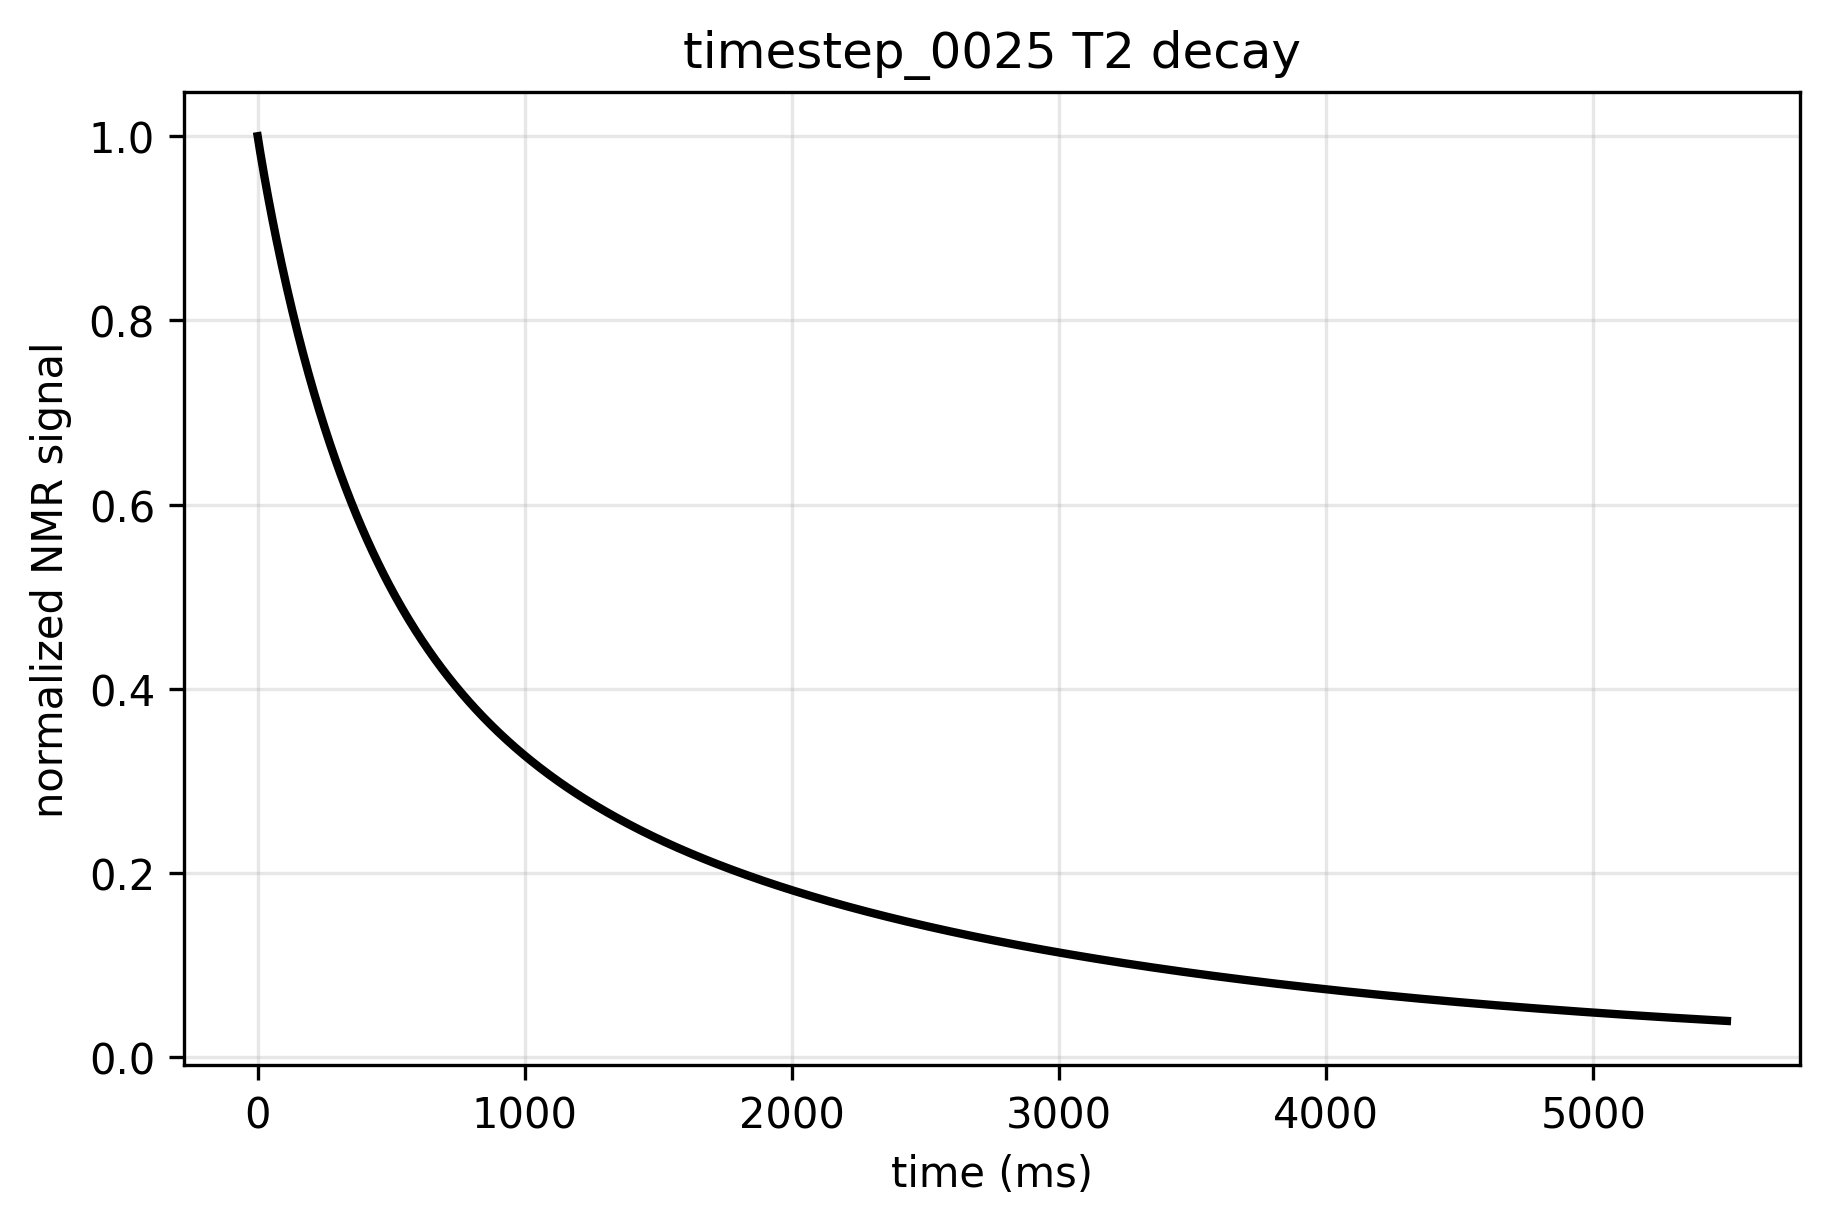

In [5]:
pixel_dir = RUN_DIR / "02_png_pixel_decay"
pixel_dir.mkdir(parents=True, exist_ok=True)

pixel_params = SimulationParams(
    pixel_size_x_um=pixel_size_x_um,
    pixel_size_y_um=pixel_size_y_um,
    diffusion_um2_per_ms=DIFFUSION_UM2_PER_MS,
    bulk_t2_ms=BULK_T2_MS,
    rho_solid_um_per_ms=RHO_SOLID_UM_PER_MS,
    rho_gas_um_per_ms=RHO_GAS_UM_PER_MS,
    dt_ms=DECAY_DT_MS,
    t_max_ms=DECAY_T_MAX_MS,
    max_grid_size=MAX_GRID_SIZE,
    solver="pixel",
    mesh_bulk_size_um=TRI_MESH_BULK_SIZE_UM,
    mesh_boundary_size_um=TRI_MESH_BOUNDARY_SIZE_UM,
    mesh_max_points=TRI_MESH_MAX_POINTS,
)

start = time.perf_counter()
pixel_summary = simulate_png(PNG_PATH, pixel_dir, pixel_params)
pixel_wall_time_s = time.perf_counter() - start

pixel_decay_csv = pixel_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.csv"
pixel_decay_png = pixel_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.png"
print(f"PNG pixel wall time: {pixel_wall_time_s:.3f} s")
display(pd.read_csv(pixel_decay_csv).head())
display(IPyImage(filename=str(pixel_decay_png)))

## 6. PNG pixel GPU decay solve

This step uses the same finite-difference operator and boundary-condition interpretation as the CPU pixel solver, but solves the implicit Euler sparse system with CuPy/CUDA.


PNG pixel GPU wall time: 2.330 s
GPU summary: {'water_pixels': 48424, 'solid_liquid_surface_over_volume_sum': 1553.7691114865893, 'gas_liquid_surface_over_volume_sum': 123.47376709095954, 'backend': 'cupy', 'gpu_solver': 'cg', 'gpu_cg_tol': 1e-08, 'gpu_cg_maxiter': 2000, 'cuda_device_count': 1, 'cuda_device_name': 'NVIDIA GeForce RTX 4070 Ti SUPER'}


,time_ms,signal,normalized_signal
0,0.0,775031.720934,1.000000
1,5.0,767870.799636,0.990760
2,10.0,760957.044975,0.981840
3,15.0,754237.400302,0.973170
4,20.0,747680.355278,0.964709


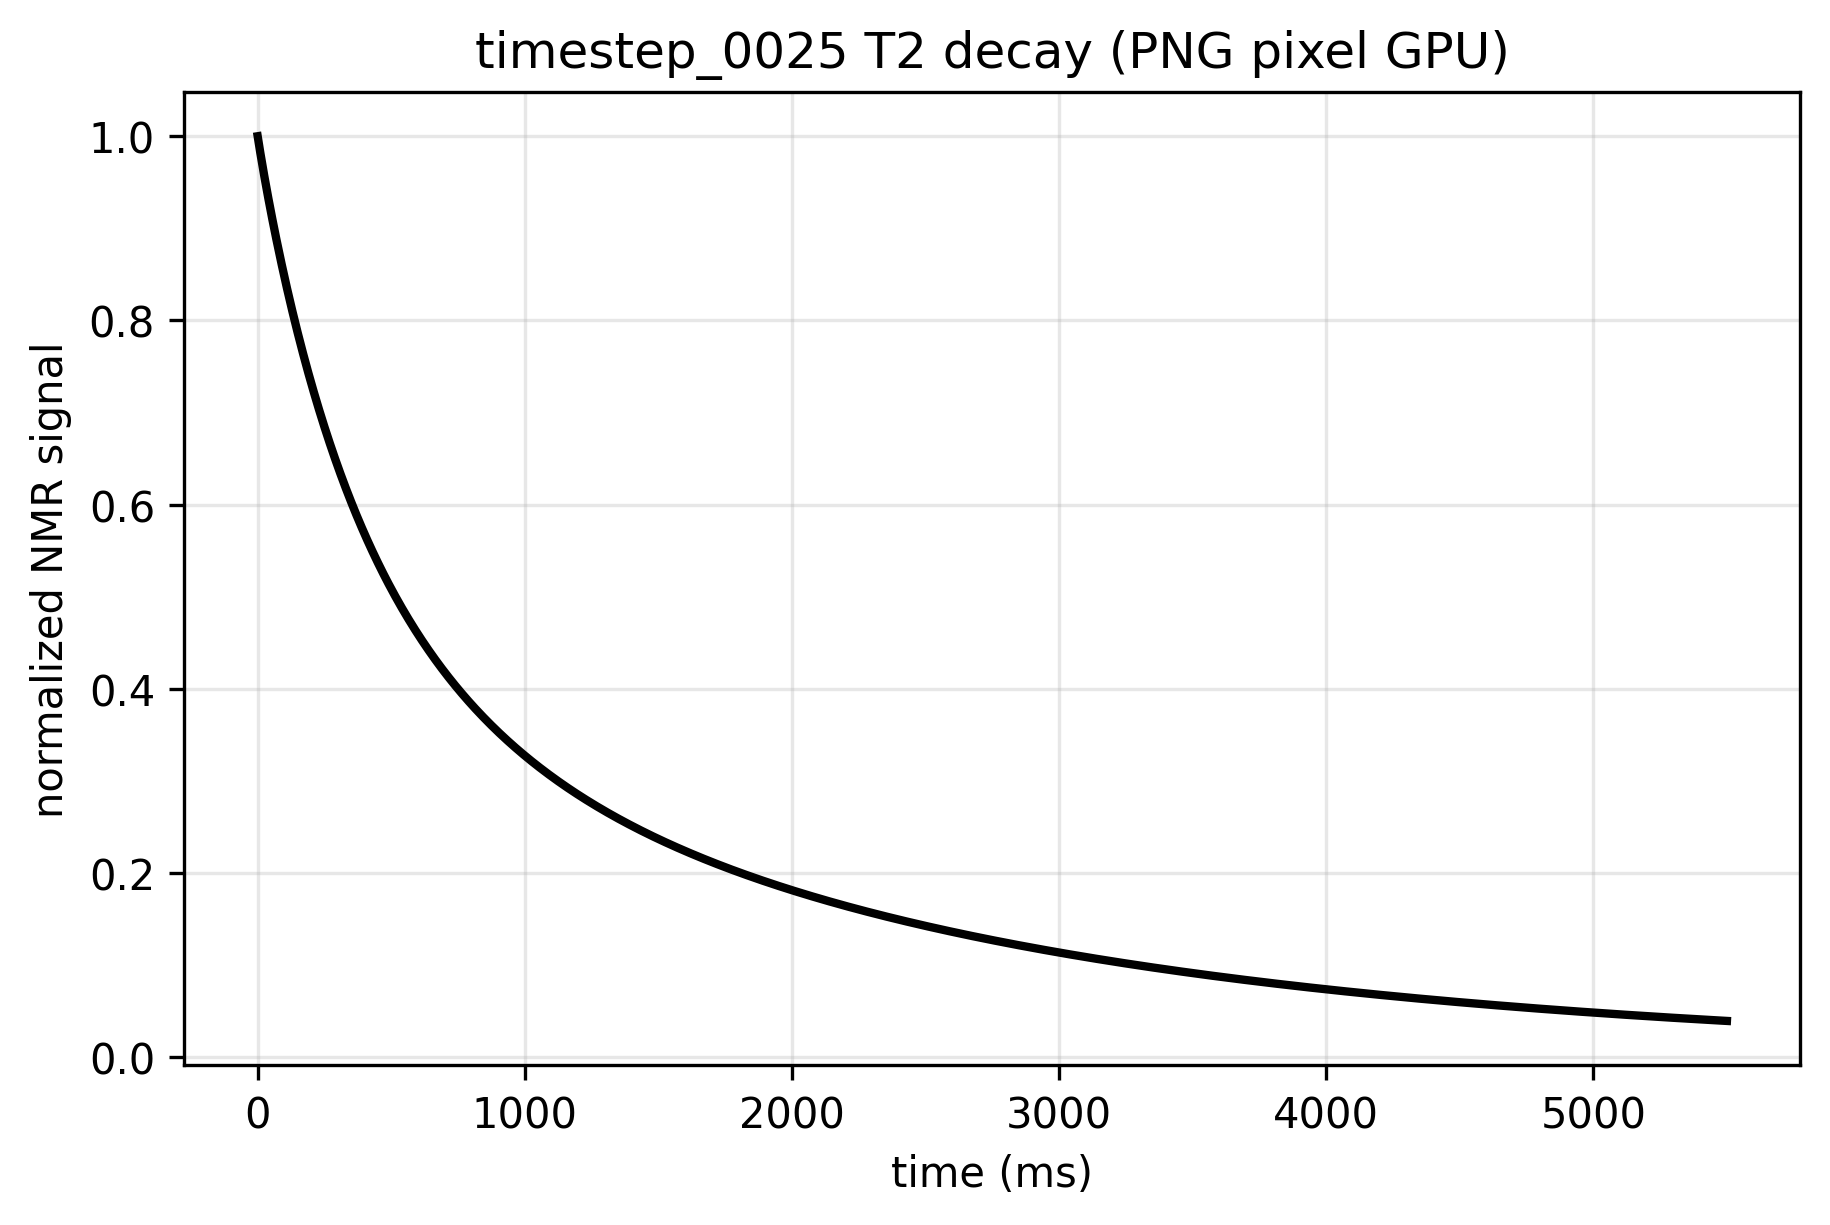

In [6]:

pixel_gpu_dir = RUN_DIR / "03_png_pixel_gpu_decay"
pixel_gpu_dir.mkdir(parents=True, exist_ok=True)

pixel_gpu_summary = None
pixel_gpu_wall_time_s = np.nan
pixel_gpu_error = ""
pixel_gpu_decay_csv = pixel_gpu_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.csv"
pixel_gpu_decay_png = pixel_gpu_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.png"

pixel_gpu_params = SimulationParams(
    pixel_size_x_um=pixel_size_x_um,
    pixel_size_y_um=pixel_size_y_um,
    diffusion_um2_per_ms=DIFFUSION_UM2_PER_MS,
    bulk_t2_ms=BULK_T2_MS,
    rho_solid_um_per_ms=RHO_SOLID_UM_PER_MS,
    rho_gas_um_per_ms=RHO_GAS_UM_PER_MS,
    dt_ms=DECAY_DT_MS,
    t_max_ms=DECAY_T_MAX_MS,
    max_grid_size=MAX_GRID_SIZE,
    solver="pixel_gpu",
    mesh_bulk_size_um=TRI_MESH_BULK_SIZE_UM,
    mesh_boundary_size_um=TRI_MESH_BOUNDARY_SIZE_UM,
    mesh_max_points=TRI_MESH_MAX_POINTS,
)

if ENABLE_PIXEL_GPU:
    if not GPU_RUNTIME_AVAILABLE:
        pixel_gpu_error = GPU_RUNTIME_MESSAGE
        print("PNG pixel GPU skipped:", pixel_gpu_error)
        if not SKIP_PIXEL_GPU_ON_ERROR:
            raise RuntimeError(pixel_gpu_error)
    else:
        # These globals are read by simulate_png_gpu_pixel(). Keeping them here
        # makes the notebook parameter cell the single place to tune GPU solve
        # behavior.
        gpu_workflow.PIXEL_GPU_SOLVER = PIXEL_GPU_SOLVER
        gpu_workflow.PIXEL_GPU_CG_TOL = PIXEL_GPU_CG_TOL
        gpu_workflow.PIXEL_GPU_CG_MAXITER = PIXEL_GPU_CG_MAXITER

        start = time.perf_counter()
        try:
            pixel_gpu_summary = gpu_workflow.simulate_png_gpu_pixel(PNG_PATH, pixel_gpu_dir, pixel_gpu_params)
            pixel_gpu_wall_time_s = time.perf_counter() - start
        except Exception as exc:
            pixel_gpu_wall_time_s = time.perf_counter() - start
            pixel_gpu_error = f"{type(exc).__name__}: {exc}"
            print("PNG pixel GPU failed:", pixel_gpu_error)
            if not SKIP_PIXEL_GPU_ON_ERROR:
                raise
        else:
            print(f"PNG pixel GPU wall time: {pixel_gpu_wall_time_s:.3f} s")
            print("GPU summary:", pixel_gpu_summary["mesh_or_boundary_summary"])
            display(pd.read_csv(pixel_gpu_decay_csv).head())
            display(IPyImage(filename=str(pixel_gpu_decay_png)))
else:
    pixel_gpu_error = "ENABLE_PIXEL_GPU=False"
    print("ENABLE_PIXEL_GPU=False, skipped PNG pixel GPU solve.")

if pixel_gpu_error:
    (pixel_gpu_dir / "gpu_skip_or_error.txt").write_text(pixel_gpu_error, encoding="utf-8")


## 7. PNG triangular mesh solve and mesh preview


Processed 1 PNG file(s).
Outputs written to: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\04_png_triangular_decay

PNG triangular wall time: 4.914 s


,time_ms,signal,normalized_signal
0,0.0,777428.419401,1.000000
1,5.0,771270.942215,0.992080
2,10.0,765311.370672,0.984414
3,15.0,759502.298260,0.976942
4,20.0,753816.336682,0.969628


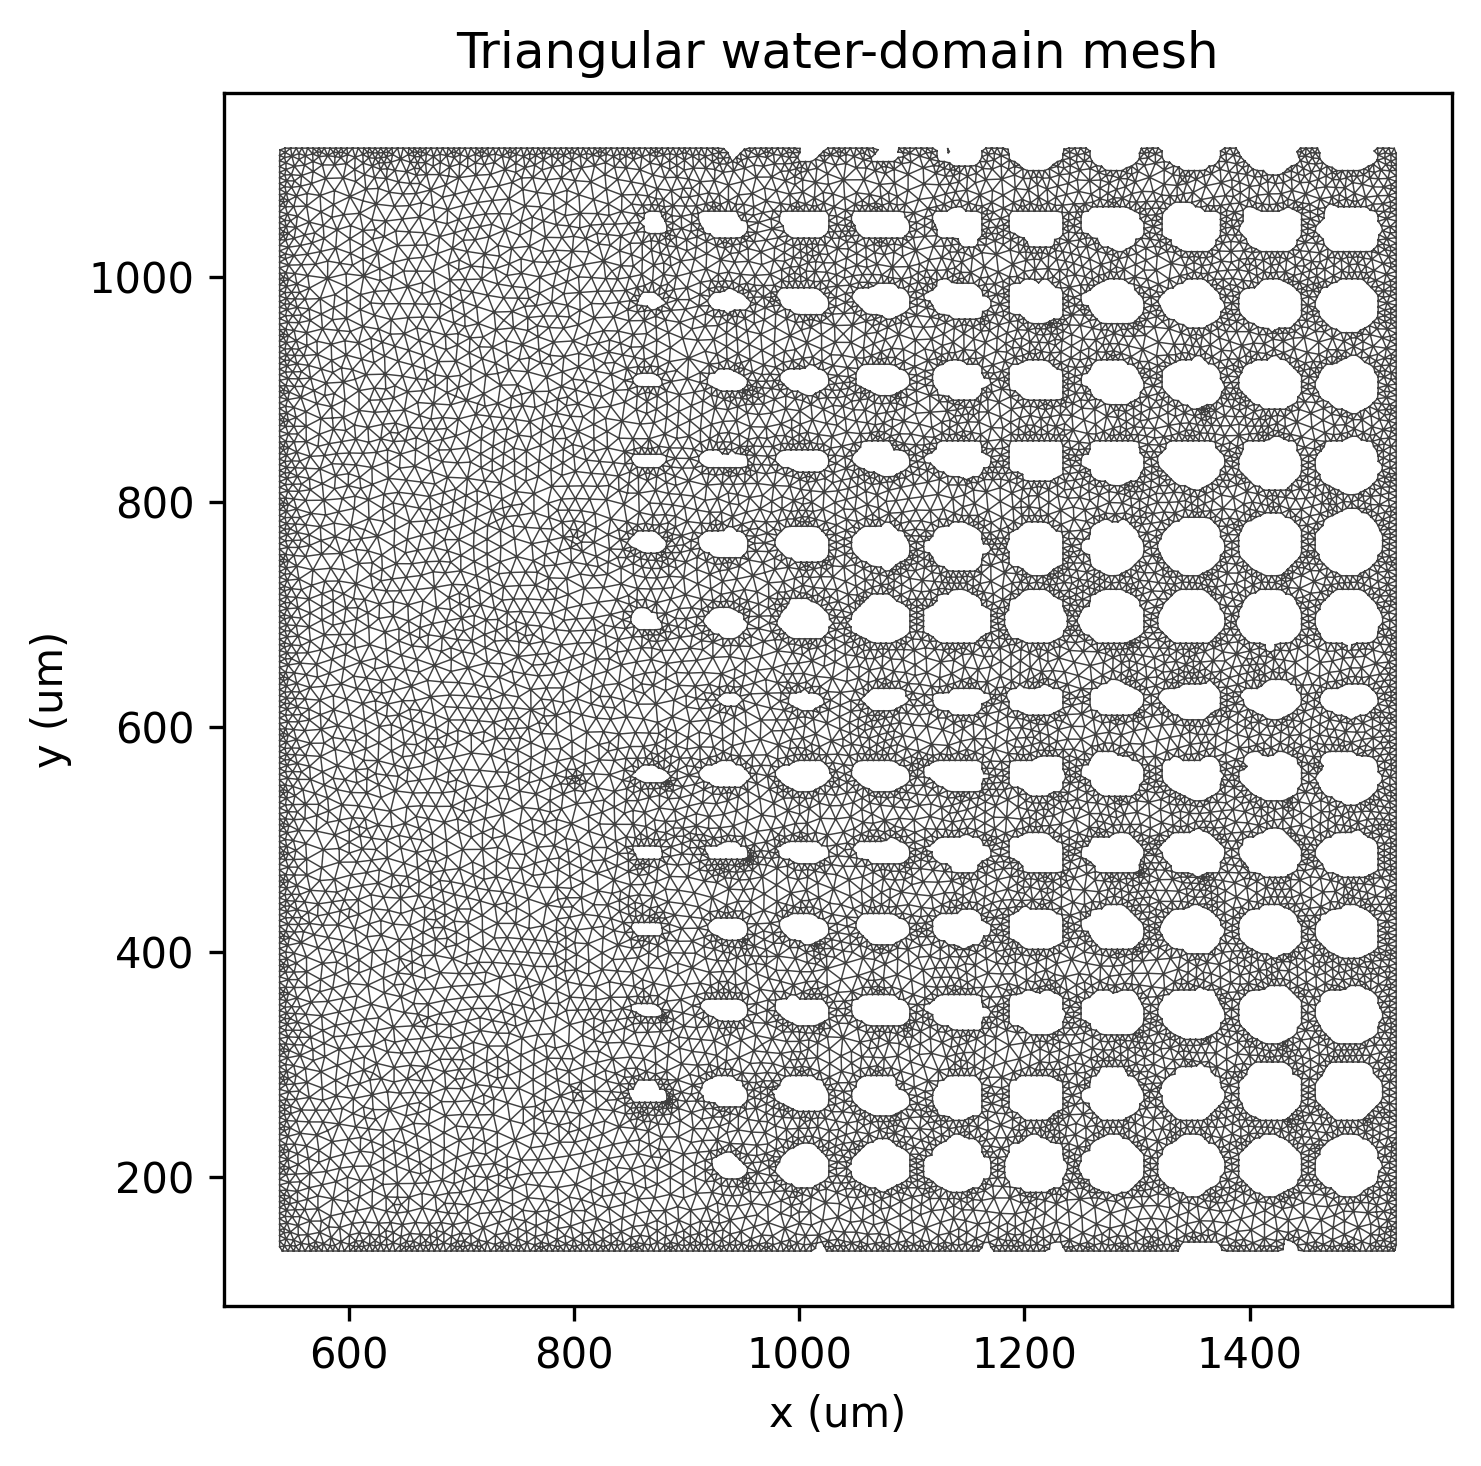

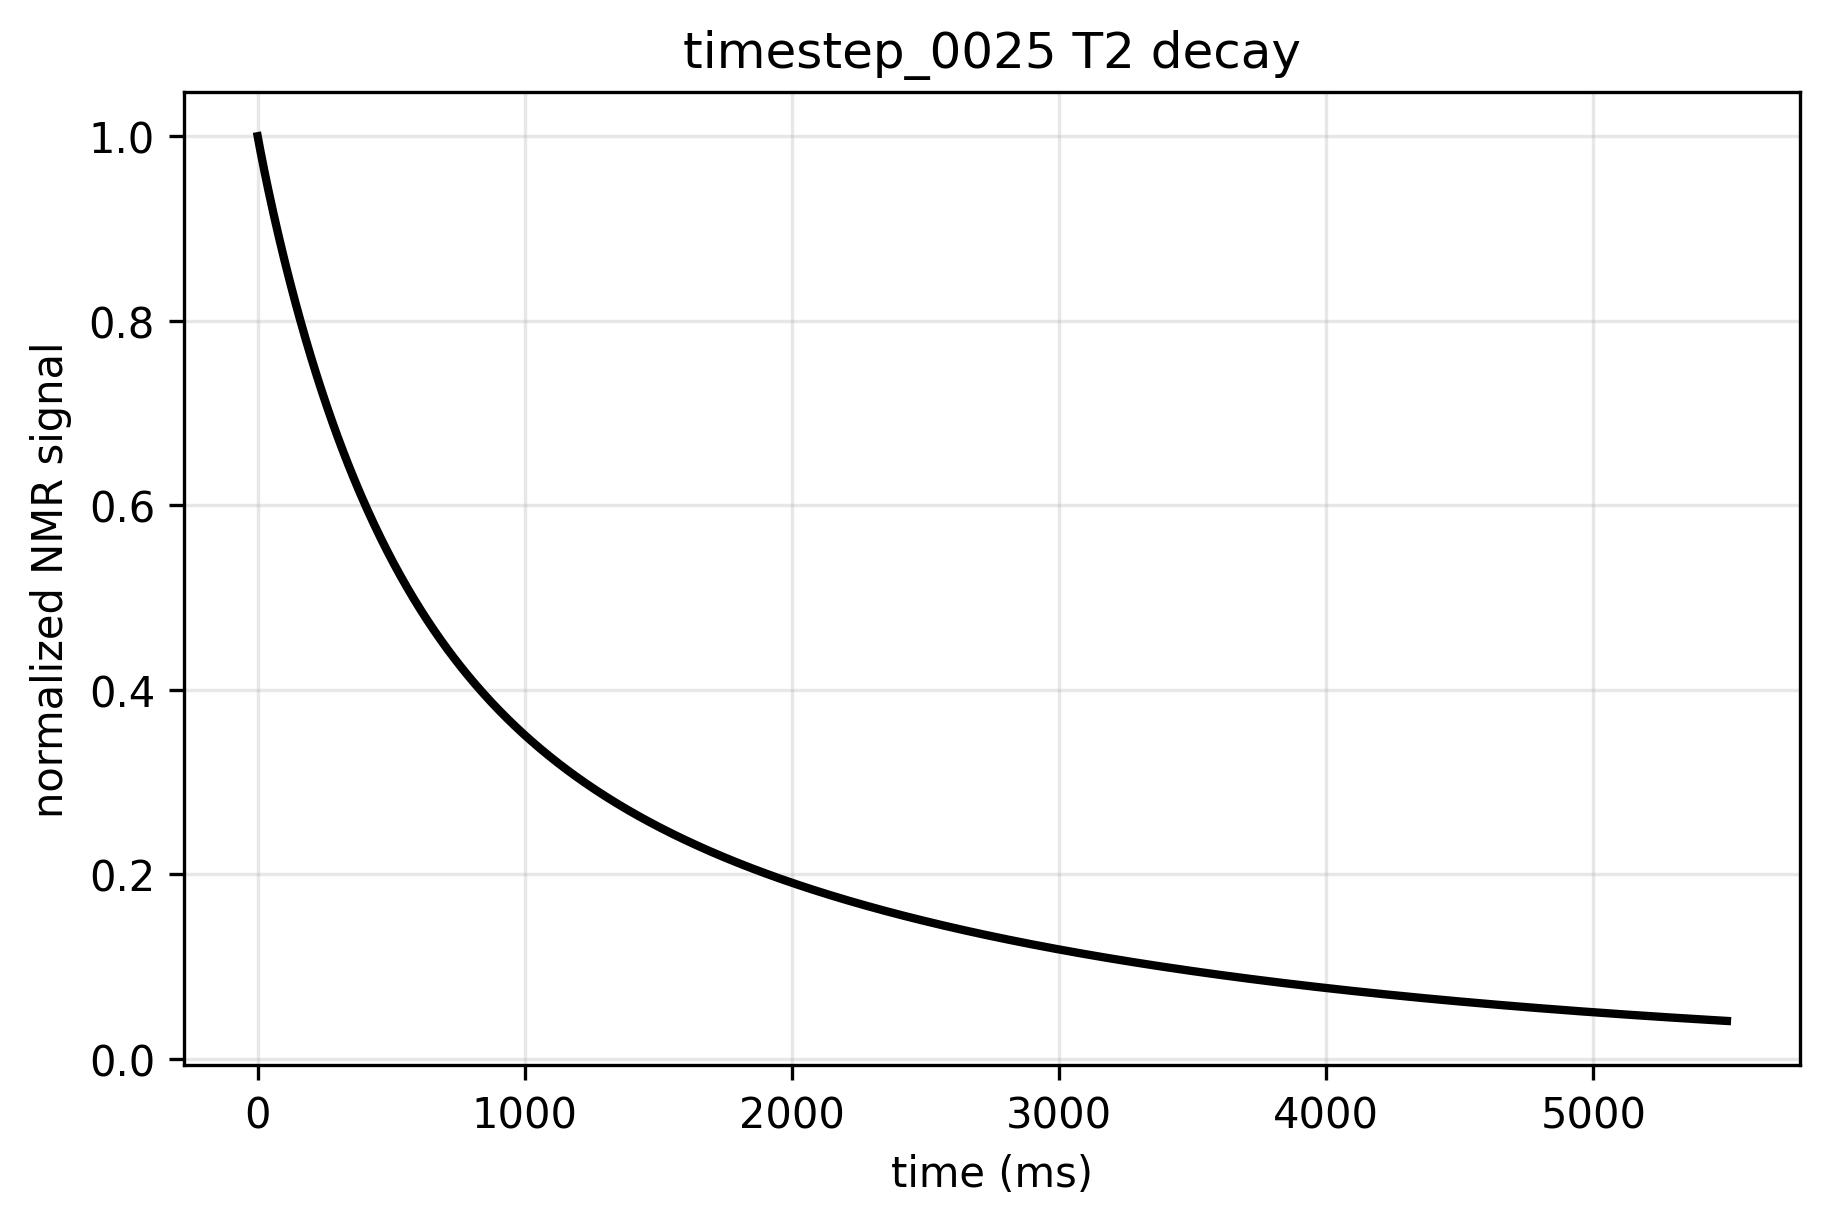

,count,mean,std,min,25%,50%,75%,max
element_id,23913.0,11956.000000,6903.232830,0.000000,5978.000000,11956.000000,17934.000000,23912.000000
node_0,23913.0,7973.857651,3798.006549,0.000000,5247.000000,8169.000000,11180.000000,14189.000000
node_1,23913.0,8038.423075,3782.978621,0.000000,5360.000000,8185.000000,11261.000000,14189.000000
node_2,23913.0,8105.423619,3721.694772,1.000000,5473.000000,8264.000000,11231.000000,14189.000000
area_um2,23913.0,32.510702,22.959170,0.148021,15.127328,23.053901,46.444113,140.736698
edge_min_um,23913.0,7.323793,2.757062,0.251122,5.000000,6.546464,9.377190,17.422937
edge_max_um,23913.0,9.305975,3.121631,0.991325,6.913201,8.482626,11.646061,20.344850
edge_mean_um,23913.0,8.346662,2.876023,0.761837,6.086054,7.485976,10.531113,18.226608
quality_equilateral_normalized,23913.0,0.943545,0.056736,0.176922,0.920956,0.960291,0.983742,0.999995
aspect_edge_ratio,23913.0,1.302105,0.214210,1.002421,1.160723,1.263424,1.396371,9.503595


In [7]:
tri_dir = RUN_DIR / "04_png_triangular_decay"
tri_dir.mkdir(parents=True, exist_ok=True)

tri_params = SimulationParams(
    pixel_size_x_um=pixel_size_x_um,
    pixel_size_y_um=pixel_size_y_um,
    diffusion_um2_per_ms=DIFFUSION_UM2_PER_MS,
    bulk_t2_ms=BULK_T2_MS,
    rho_solid_um_per_ms=RHO_SOLID_UM_PER_MS,
    rho_gas_um_per_ms=RHO_GAS_UM_PER_MS,
    dt_ms=DECAY_DT_MS,
    t_max_ms=DECAY_T_MAX_MS,
    max_grid_size=MAX_GRID_SIZE,
    solver="triangular",
    mesh_bulk_size_um=TRI_MESH_BULK_SIZE_UM,
    mesh_boundary_size_um=TRI_MESH_BOUNDARY_SIZE_UM,
    mesh_max_points=TRI_MESH_MAX_POINTS,
)

start = time.perf_counter()
if CURRENT_PYTHON_HAS_PYGIMLI:
    tri_summary = simulate_png(PNG_PATH, tri_dir, tri_params)
else:
    cmd = [
        str(PYGIMLI_FALLBACK_PYTHON), str(PNG_DECAY_SCRIPT), str(PNG_PATH),
        "--output-dir", str(tri_dir),
        "--pixel-size-x-um", str(pixel_size_x_um),
        "--pixel-size-y-um", str(pixel_size_y_um),
        "--diffusion-um2-per-ms", str(DIFFUSION_UM2_PER_MS),
        "--bulk-t2-ms", str(BULK_T2_MS),
        "--rho-solid-um-per-ms", str(RHO_SOLID_UM_PER_MS),
        "--rho-gas-um-per-ms", str(RHO_GAS_UM_PER_MS),
        "--dt-ms", str(DECAY_DT_MS),
        "--t-max-ms", str(DECAY_T_MAX_MS),
        "--max-grid-size", str(MAX_GRID_SIZE),
        "--solver", "triangular",
        "--mesh-bulk-size-um", str(TRI_MESH_BULK_SIZE_UM),
        "--mesh-boundary-size-um", str(TRI_MESH_BOUNDARY_SIZE_UM),
        "--mesh-max-points", str(TRI_MESH_MAX_POINTS),
    ]
    env = dict(os.environ)
    env["PYTHONIOENCODING"] = "utf-8"
    env["MPLBACKEND"] = "Agg"
    completed = subprocess.run(
        cmd,
        check=False,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
        env=env,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.returncode != 0:
        print("Subprocess command failed:")
        print(" ".join(str(x) for x in cmd))
        print("--- stdout ---")
        print(completed.stdout)
        print("--- stderr ---")
        print(completed.stderr)
        raise RuntimeError(f"Triangular mesh subprocess failed with return code {completed.returncode}")
tri_wall_time_s = time.perf_counter() - start

tri_decay_csv = tri_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.csv"
tri_decay_png = tri_dir / f"timestep_{TIMESTEP:04d}_nmr_decay.png"
tri_mesh_png = tri_dir / f"timestep_{TIMESTEP:04d}_triangular_mesh.png"
tri_quality_csv = tri_dir / f"timestep_{TIMESTEP:04d}_mesh_quality.csv"

print(f"PNG triangular wall time: {tri_wall_time_s:.3f} s")
display(pd.read_csv(tri_decay_csv).head())
if tri_mesh_png.exists():
    display(IPyImage(filename=str(tri_mesh_png)))
display(IPyImage(filename=str(tri_decay_png)))
if tri_quality_csv.exists():
    display(pd.read_csv(tri_quality_csv).describe().T.head(10))


## 8. COMSOL / PNG pixel CPU / PNG pixel GPU / PNG triangular T2 comparison


c:\Users\imgw\.conda\envs\ml\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\imgw\AppData\Local\Temp\ipykernel_42672\3450506039.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,timestep,comsol_peak_t2_ms,png_pixel_cpu_peak_t2_ms,png_triangular_peak_t2_ms,png_pixel_cpu_wall_time_s,png_pixel_gpu_wall_time_s,png_triangular_wall_time_s,png_pixel_gpu_error,png_pixel_gpu_peak_t2_ms,pixel_cpu_gpu_max_abs_signal_diff
0,25,524.403126,734.69788,934.784058,5.145001,2.329757,4.913979,,734.69788,5.522084e-08


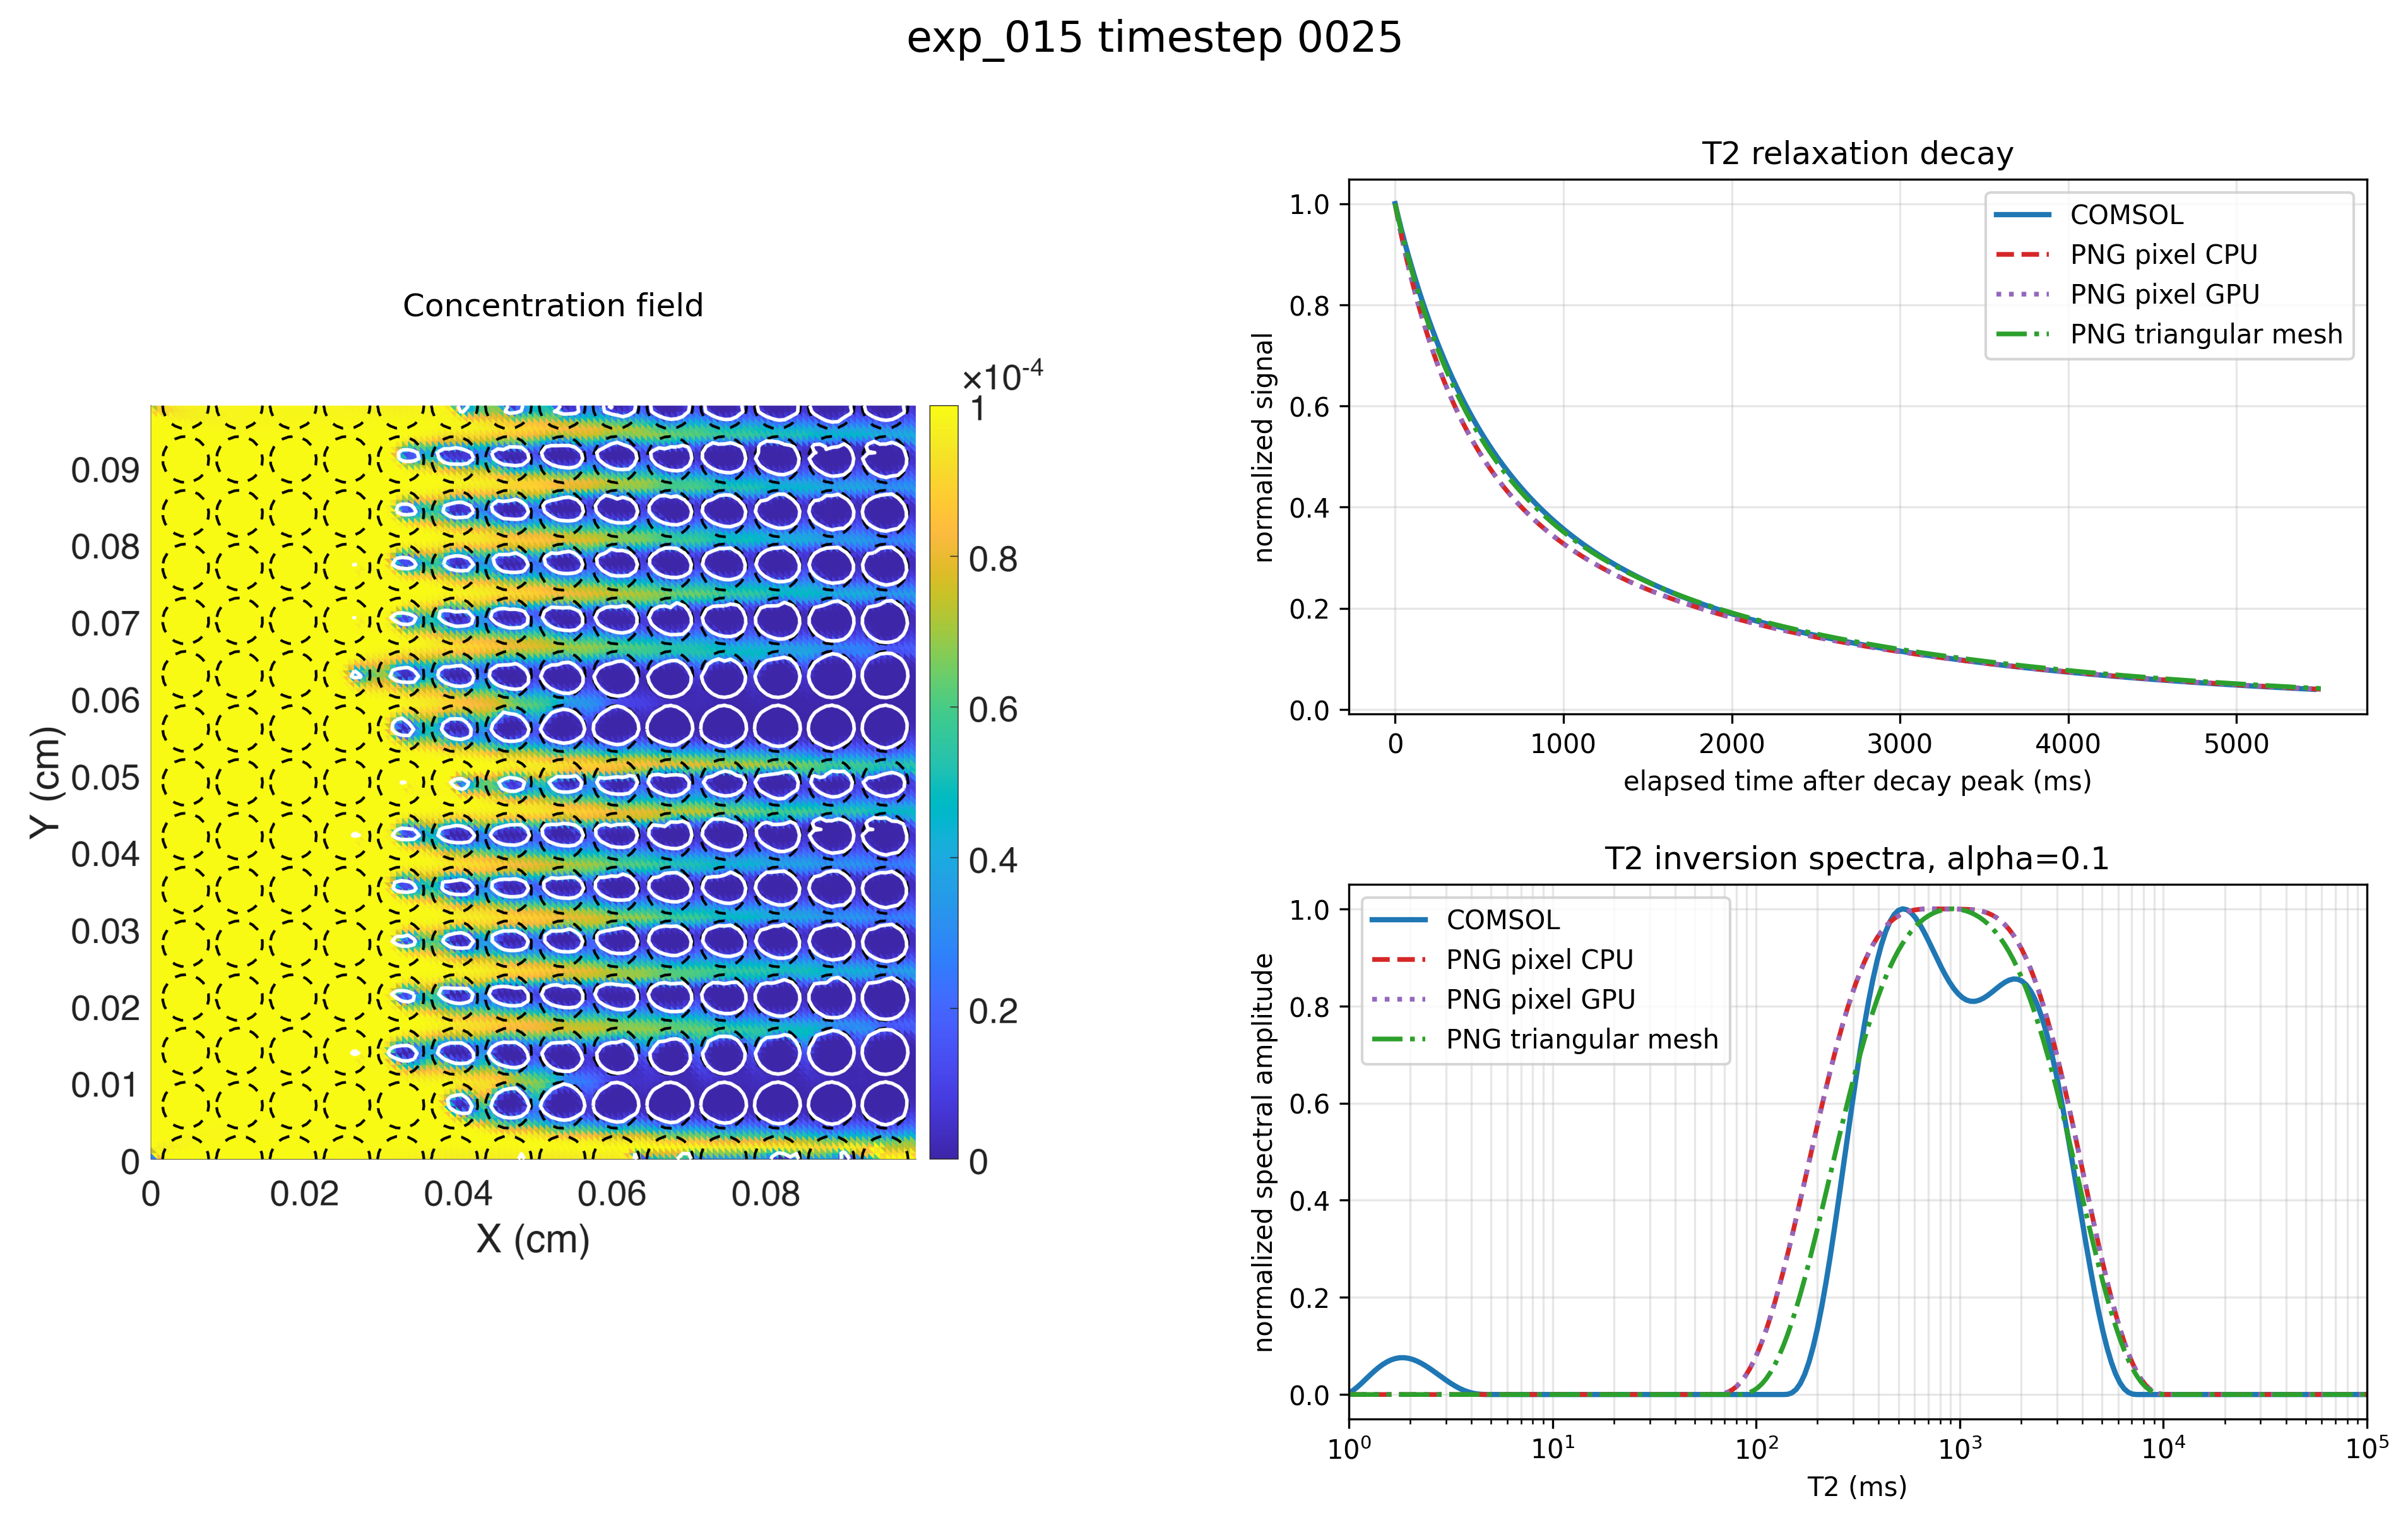

In [8]:

comparison_dir = RUN_DIR / "05_comparison"
comparison_dir.mkdir(parents=True, exist_ok=True)

comsol_t_raw, comsol_s_raw = read_comsol_probe_excel(COMSOL_XLSX)
pixel_t_raw, pixel_s_raw = read_png_decay_csv(pixel_decay_csv)
tri_t_raw, tri_s_raw = read_png_decay_csv(tri_decay_csv)

comsol_t, comsol_s, comsol_peak = trim_to_decay(comsol_t_raw, comsol_s_raw)
pixel_t, pixel_s, pixel_peak = trim_to_decay(pixel_t_raw, pixel_s_raw)
tri_t, tri_s, tri_peak = trim_to_decay(tri_t_raw, tri_s_raw)

comsol_inv = invert_fixed_alpha(comsol_t, comsol_s, name="COMSOL", alpha=NNLS_ALPHA, t2_min_ms=T2_MIN_MS, t2_max_ms=T2_MAX_MS, num_bins=T2_NUM_BINS)
pixel_inv = invert_fixed_alpha(pixel_t, pixel_s, name="PNG_pixel", alpha=NNLS_ALPHA, t2_min_ms=T2_MIN_MS, t2_max_ms=T2_MAX_MS, num_bins=T2_NUM_BINS)
tri_inv = invert_fixed_alpha(tri_t, tri_s, name="PNG_triangular", alpha=NNLS_ALPHA, t2_min_ms=T2_MIN_MS, t2_max_ms=T2_MAX_MS, num_bins=T2_NUM_BINS)

comsol_spec = comsol_inv.spectrum / max(np.max(comsol_inv.spectrum), 1e-30)
pixel_spec = pixel_inv.spectrum / max(np.max(pixel_inv.spectrum), 1e-30)
tri_spec = tri_inv.spectrum / max(np.max(tri_inv.spectrum), 1e-30)

have_pixel_gpu = ENABLE_PIXEL_GPU and pixel_gpu_decay_csv.exists()
if have_pixel_gpu:
    pixel_gpu_t_raw, pixel_gpu_s_raw = read_png_decay_csv(pixel_gpu_decay_csv)
    pixel_gpu_t, pixel_gpu_s, pixel_gpu_peak = trim_to_decay(pixel_gpu_t_raw, pixel_gpu_s_raw)
    pixel_gpu_inv = invert_fixed_alpha(pixel_gpu_t, pixel_gpu_s, name="PNG_pixel_GPU", alpha=NNLS_ALPHA, t2_min_ms=T2_MIN_MS, t2_max_ms=T2_MAX_MS, num_bins=T2_NUM_BINS)
    pixel_gpu_spec = pixel_gpu_inv.spectrum / max(np.max(pixel_gpu_inv.spectrum), 1e-30)
else:
    pixel_gpu_t = pixel_gpu_s = pixel_gpu_spec = None
    pixel_gpu_inv = None

# Optional concentration panel for context.
fig = plt.figure(figsize=(16, 8.5), dpi=160)
gs = fig.add_gridspec(2, 2, width_ratios=[1.05, 1.0], height_ratios=[1, 1], wspace=0.25, hspace=0.32)
ax_img = fig.add_subplot(gs[:, 0])
ax_decay = fig.add_subplot(gs[0, 1])
ax_t2 = fig.add_subplot(gs[1, 1])

if CONCENTRATION_PNG.exists():
    ax_img.imshow(Image.open(CONCENTRATION_PNG).convert("RGB"))
    ax_img.set_title("Concentration field")
else:
    ax_img.imshow(rgb)
    ax_img.set_title("Input phase map")
ax_img.set_axis_off()

ax_decay.plot(comsol_t, normalize(comsol_s), color="#1f77b4", lw=2.0, label="COMSOL")
ax_decay.plot(pixel_t, normalize(pixel_s), color="#d62728", lw=1.8, ls="--", label="PNG pixel CPU")
if have_pixel_gpu:
    ax_decay.plot(pixel_gpu_t, normalize(pixel_gpu_s), color="#9467bd", lw=1.8, ls=":", label="PNG pixel GPU")
ax_decay.plot(tri_t, normalize(tri_s), color="#2ca02c", lw=1.8, ls="-.", label="PNG triangular mesh")
ax_decay.set_xlabel("elapsed time after decay peak (ms)")
ax_decay.set_ylabel("normalized signal")
ax_decay.set_title("T2 relaxation decay")
ax_decay.grid(alpha=0.3)
ax_decay.legend()

ax_t2.plot(comsol_inv.t2_bins_ms, comsol_spec, color="#1f77b4", lw=2.0, label="COMSOL")
ax_t2.plot(pixel_inv.t2_bins_ms, pixel_spec, color="#d62728", lw=1.8, ls="--", label="PNG pixel CPU")
if have_pixel_gpu:
    ax_t2.plot(pixel_gpu_inv.t2_bins_ms, pixel_gpu_spec, color="#9467bd", lw=1.8, ls=":", label="PNG pixel GPU")
ax_t2.plot(tri_inv.t2_bins_ms, tri_spec, color="#2ca02c", lw=1.8, ls="-.", label="PNG triangular mesh")
ax_t2.set_xscale("log")
ax_t2.set_xlim(T2_MIN_MS, T2_MAX_MS)
ax_t2.set_xlabel("T2 (ms)")
ax_t2.set_ylabel("normalized spectral amplitude")
ax_t2.set_title(f"T2 inversion spectra, alpha={NNLS_ALPHA:g}")
ax_t2.grid(alpha=0.3, which="both")
ax_t2.legend()

fig.suptitle(f"{EXP_DIR.name} timestep {TIMESTEP:04d}", fontsize=16)
comparison_png = comparison_dir / f"timestep_{TIMESTEP:04d}_four_way_comparison.png"
fig.savefig(comparison_png, dpi=300, bbox_inches="tight")
plt.show()

t2_export = pd.DataFrame({
    "t2_ms": comsol_inv.t2_bins_ms,
    "comsol_spectrum_norm": comsol_spec,
    "png_pixel_cpu_spectrum_norm": pixel_spec,
    "png_triangular_spectrum_norm": tri_spec,
})
if have_pixel_gpu:
    t2_export["png_pixel_gpu_spectrum_norm"] = pixel_gpu_spec
t2_export.to_csv(comparison_dir / f"timestep_{TIMESTEP:04d}_t2_spectrum_comparison.csv", index=False)

summary_row = {
    "timestep": TIMESTEP,
    "comsol_peak_t2_ms": float(comsol_inv.t2_bins_ms[int(np.argmax(comsol_inv.spectrum))]),
    "png_pixel_cpu_peak_t2_ms": float(pixel_inv.t2_bins_ms[int(np.argmax(pixel_inv.spectrum))]),
    "png_triangular_peak_t2_ms": float(tri_inv.t2_bins_ms[int(np.argmax(tri_inv.spectrum))]),
    "png_pixel_cpu_wall_time_s": pixel_wall_time_s,
    "png_pixel_gpu_wall_time_s": pixel_gpu_wall_time_s,
    "png_triangular_wall_time_s": tri_wall_time_s,
    "png_pixel_gpu_error": pixel_gpu_error,
}
if have_pixel_gpu:
    summary_row["png_pixel_gpu_peak_t2_ms"] = float(pixel_gpu_inv.t2_bins_ms[int(np.argmax(pixel_gpu_inv.spectrum))])
    summary_row["pixel_cpu_gpu_max_abs_signal_diff"] = float(np.max(np.abs(normalize(pixel_s) - normalize(pixel_gpu_s)))) if pixel_s.shape == pixel_gpu_s.shape else np.nan

summary = pd.DataFrame([summary_row])
summary.to_csv(RUN_DIR / "single_timestep_summary.csv", index=False)
display(summary)
display(IPyImage(filename=str(comparison_png)))


## 9. Output overview


Run directory: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836
Geometry: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\01_geometry
PNG pixel CPU decay: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\02_png_pixel_decay
PNG pixel GPU decay: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\03_png_pixel_gpu_decay
PNG triangular decay: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\04_png_triangular_decay
Comparison: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\exp_015\single_timestep_nmr_demo_t0025_20260528_160836\05_comparison
Summary CSV: C:\Users\imgw\Documents\Codex\RTSPHEM-main\outputs\rtm_batches\33\ex

C:\Users\imgw\AppData\Local\Temp\ipykernel_42672\2796164372.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


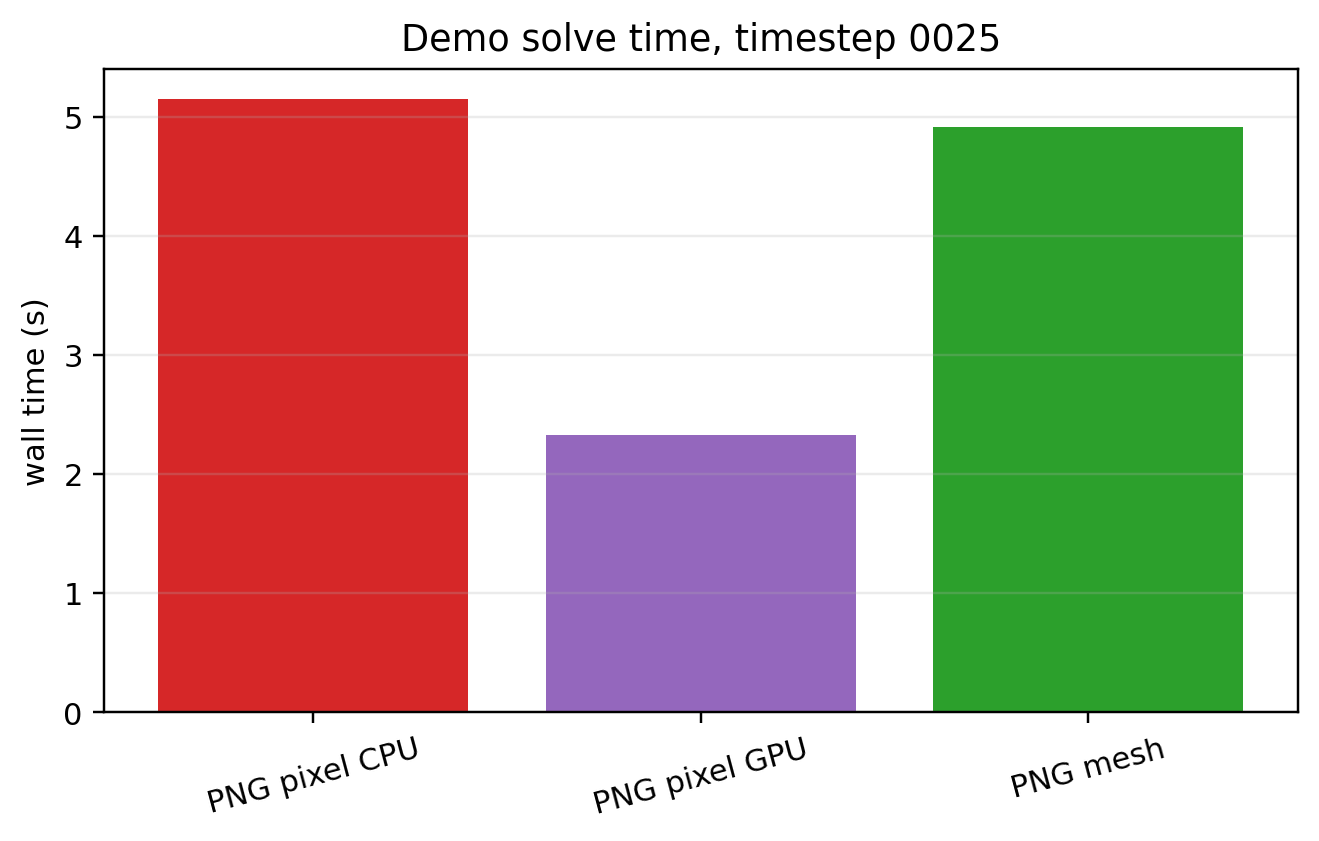

In [9]:

print("Run directory:", RUN_DIR)
print("Geometry:", geometry_dir)
print("PNG pixel CPU decay:", pixel_dir)
print("PNG pixel GPU decay:", pixel_gpu_dir)
if pixel_gpu_error:
    print("PNG pixel GPU note:", pixel_gpu_error)
print("PNG triangular decay:", tri_dir)
print("Comparison:", comparison_dir)
print("Summary CSV:", RUN_DIR / "single_timestep_summary.csv")

# Small timing bar plot for this demo timestep.
labels = ["PNG pixel CPU", "PNG mesh"]
values = [pixel_wall_time_s, tri_wall_time_s]
colors = ["#d62728", "#2ca02c"]
if ENABLE_PIXEL_GPU and not np.isnan(pixel_gpu_wall_time_s):
    labels.insert(1, "PNG pixel GPU")
    values.insert(1, pixel_gpu_wall_time_s)
    colors.insert(1, "#9467bd")

timing_fig, ax = plt.subplots(figsize=(7.0, 3.8), dpi=160)
ax.bar(labels, values, color=colors)
ax.set_ylabel("wall time (s)")
ax.set_title(f"Demo solve time, timestep {TIMESTEP:04d}")
ax.grid(alpha=0.25, axis="y")
ax.tick_params(axis="x", rotation=15)
timing_png = RUN_DIR / "single_timestep_timing.png"
timing_fig.savefig(timing_png, dpi=220, bbox_inches="tight")
plt.show()
display(IPyImage(filename=str(timing_png)))
